# Day-Ahead Price Forecast — Exploratory Data Analysis

**Goal:** Understand the structure, quality, and dynamics of the DE-LU day-ahead electricity
market data before modelling. The analysis covers data-quality checks (missingness, gaps,
plausibility) and structural insights (merit-order effect, seasonality, regime shifts,
cross-border price–flow relationships).

**Time range:** 2019-01-01 to yesterday (UTC). The full range deliberately spans the
pre- and post-2022 energy-crisis regimes, enabling regime-change analysis.

**Data sources:**
- ENTSO-E Transparency Platform (via `entsoe-py`): day-ahead prices, load, wind/solar
  forecasts and actuals, generation mix, scheduled exchanges, cross-border flows.
- Yahoo Finance (via `yfinance`): TTF Natural Gas Futures (`TTF=F`), EUA CO₂ Allowances (`CO2.L`).

**Last refresh:** _YYYY-MM-DD — update manually when re-running_

**Out of scope:** Feature engineering, modelling, and dashboards.
Those live in separate notebooks and scripts.

## 1. Setup and Data Loading

In [1]:
import logging
import warnings
from typing import Sequence

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns

from energy_price_forecast.data.loaders import load_all_data

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.max_columns = 100
pd.options.display.width = 200
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

In [2]:
START = pd.Timestamp("2019-01-01", tz="UTC")
END = pd.Timestamp.utcnow().normalize() - pd.Timedelta(days=1)

df = load_all_data(START, END)
df.shape, df.index.min(), df.index.max()

INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-01.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-02.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-03.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-04.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-05.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-06.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-07.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-08.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-09.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-10.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-11.parquet
INFO energy_price_forecast.data._entsoe_cache: Cache hit: DE_LU_2019-12.parquet
INFO energy_price_forecast.data._entsoe_

((82087, 34),
 Timestamp('2019-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2026-05-28 00:00:00+0000', tz='UTC'))

> **Runtime note:** The first run fetches ~6 years of ENTSO-E data via API and takes several
> minutes. Subsequent runs read from the monthly Parquet cache and complete in seconds.

## 2. Data Quality Checks

### 2.1 Raw Time Series Inspection

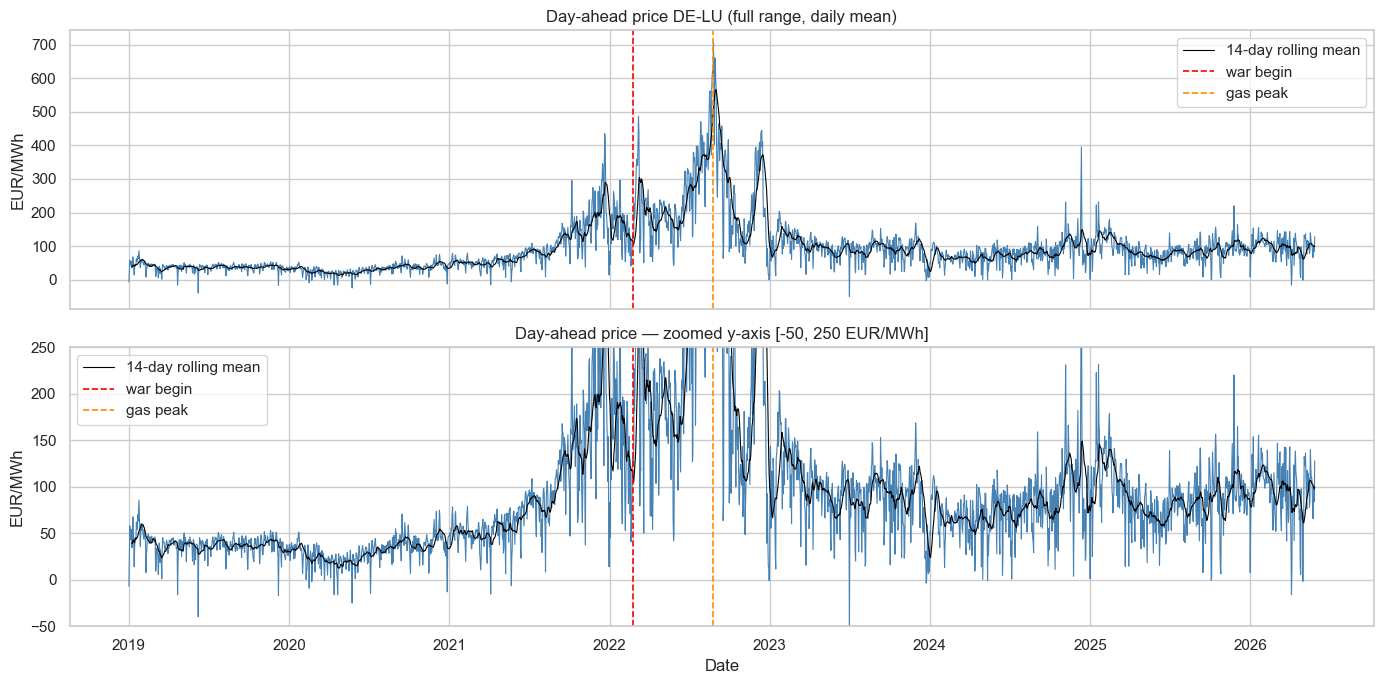

In [18]:
WAR_DATE = pd.Timestamp("2022-02-24", tz="UTC")
GAS_PEAK_DATE = pd.Timestamp("2022-08-26", tz="UTC")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

daily_price = df["day_ahead_price"].resample("D").mean()
rolling_30 = daily_price.rolling(14, min_periods=7).mean()

ax1.plot(daily_price.index, daily_price.values, lw=0.8, color="steelblue")
ax1.plot(rolling_30.index, rolling_30.values, lw=0.8, color="black", label="14-day rolling mean")
ax1.axvline(WAR_DATE, color="red", lw=1.2, linestyle="--", label="war begin")
ax1.axvline(GAS_PEAK_DATE, color="darkorange", lw=1.2, linestyle="--", label="gas peak")
ax1.set_title("Day-ahead price DE-LU (full range, daily mean)")
ax1.set_ylabel("EUR/MWh")
ax1.legend()

ax2.plot(daily_price.index, daily_price.values, lw=0.8, color="steelblue")
ax2.plot(rolling_30.index, rolling_30.values, lw=0.8, color="black", label="14-day rolling mean")
ax2.axvline(WAR_DATE, color="red", lw=1.2, linestyle="--", label="war begin")
ax2.axvline(GAS_PEAK_DATE, color="darkorange", lw=1.2, linestyle="--", label="gas peak")
ax2.set_ylim(-50, 250)
ax2.set_title("Day-ahead price \u2014 zoomed y-axis [-50, 250 EUR/MWh]")
ax2.set_ylabel("EUR/MWh")
ax2.set_xlabel("Date")
ax2.legend()

plt.tight_layout()
plt.show()

The pre-2022 price level is consistently below 100 EUR/MWh with occasional spikes; from mid-2021 onward prices surge sharply, peaking in August 2022 following the Russian invasion of Ukraine and the TTF gas-price peak. Prices gradually mean-revert from 2023 onward. The post-crisis mean and variance remain higher, however. Negative prices are present but rare; the zoomed panel reveals the regular daily/seasonal structure that is hidden by the 2022 extremes in the full-scale view. The price data is as expected.

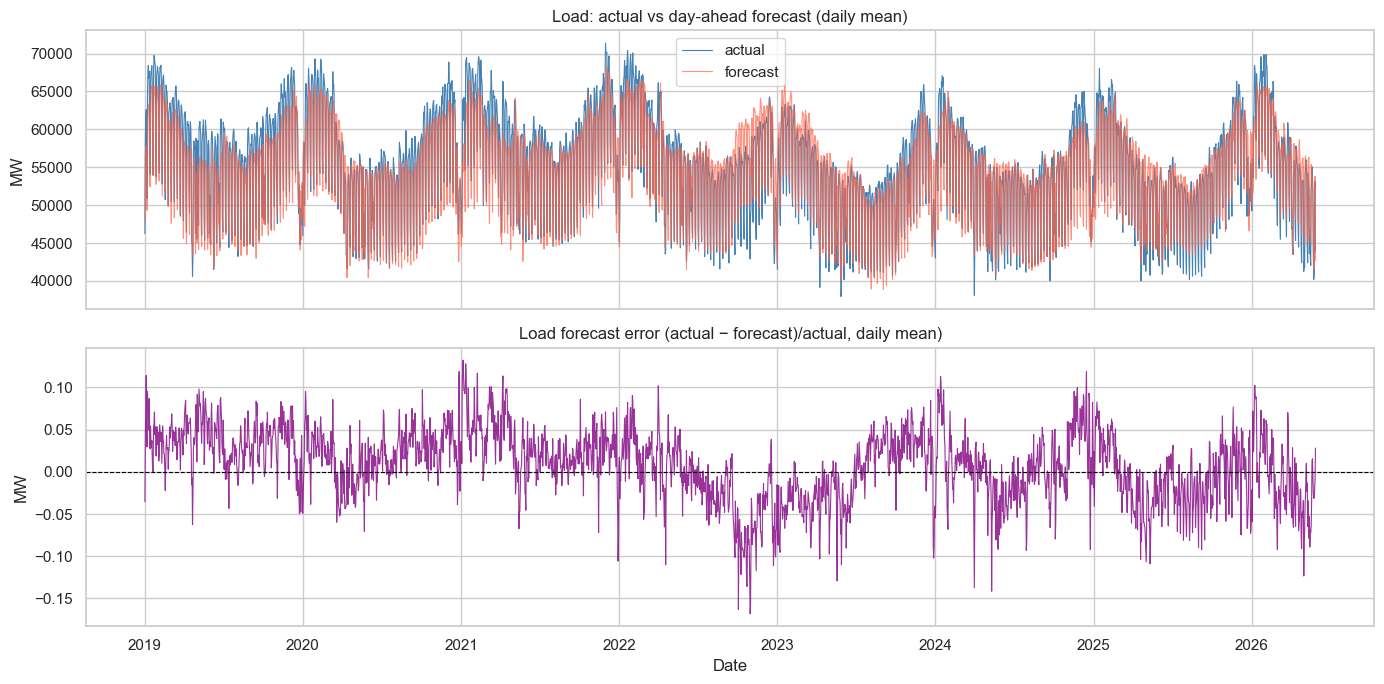

In [19]:
daily_load = df[["load_actual", "load_forecast_day_ahead"]].resample("D").mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(
    daily_load.index, daily_load["load_actual"],
    lw=0.8, label="actual", color="steelblue",
)
ax1.plot(
    daily_load.index, daily_load["load_forecast_day_ahead"],
    lw=0.8, label="forecast", color="tomato", alpha=0.7,
)
ax1.set_title("Load: actual vs day-ahead forecast (daily mean)")
ax1.set_ylabel("MW")
ax1.legend()

daily_error = ((df["load_actual"] - df["load_forecast_day_ahead"])/df["load_actual"]).resample("D").mean()
ax2.plot(daily_error.index, daily_error.values, lw=0.8, color="purple", alpha=0.8)
ax2.axhline(0, color="black", lw=0.8, linestyle="--")
ax2.set_title("Load forecast error (actual − forecast)/actual, daily mean)")
ax2.set_ylabel("MW")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

Load shows clear seasonal structure: winter peaks significantly higher than summer troughs, consistent across all years. The crisis can be seen only subtle: The load dips sligthly in 2022 in comparison to the years before and is over the years slowly mean reverting, which is plaubile, because of less economic activities and a consumption decrease due to higher prices. The forecast tracks actual load very closely. The error shows a clearer behavioral shift: Pre-crisis, the forecast was slightly underestimating the load. In the crisis, the load dip results in strong overestimations. Post-crisis, it is well centered but oscilating stronger with a visible seasonal trend. Possible drivers include demand destruction in heavy industry, increased heat-pump penetration, growing behind-the-meter PV self-consumption, and government-driven energy-saving campaigns.

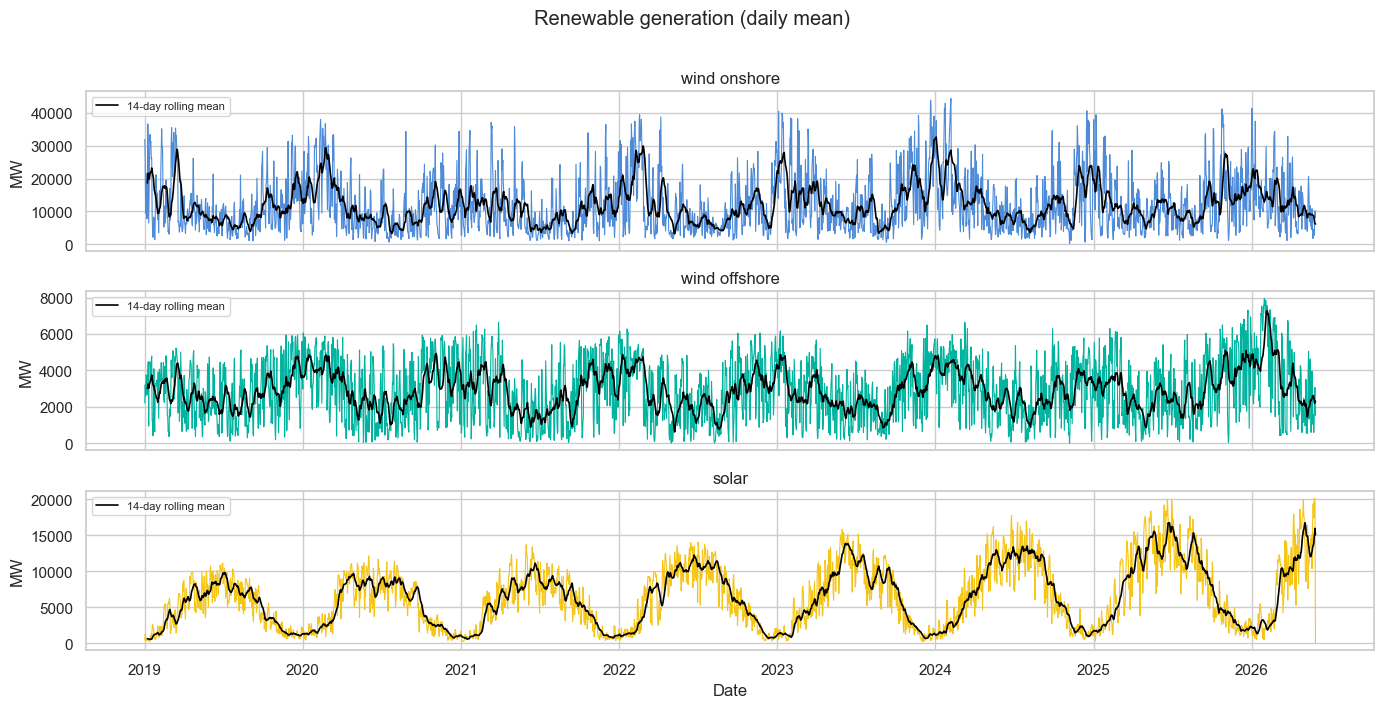

In [20]:
renew_cols = ["gen_wind_onshore", "gen_wind_offshore", "gen_solar"]
available_renew = [c for c in renew_cols if c in df.columns]
daily_renew = df[available_renew].resample("D").mean()

RENEW_COLORS = {
    "gen_wind_onshore": "#4e8bd9",
    "gen_wind_offshore": "#00b4a0",
    "gen_solar": "#f5c518",
}

fig, axes = plt.subplots(len(available_renew), 1, figsize=(14, 7), sharex=True)
for ax, col in zip(axes, available_renew):
    rolling = daily_renew[col].rolling(14, min_periods=7).mean()
    ax.plot(daily_renew.index, daily_renew[col], lw=0.8, color=RENEW_COLORS[col])
    ax.plot(rolling.index, rolling.values, lw=1.2, color="black", label="14-day rolling mean")
    ax.set_ylabel("MW")
    ax.set_title(col.replace("gen_", "").replace("_", " "))
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Date")
fig.suptitle("Renewable generation (daily mean)", y=1.01)
plt.tight_layout()
plt.show()

Wind generation (onshore + offshore) peaks in winter months while solar peaks in summer — the two sources are naturally anti-correlated seasonally, providing partial complementarity. A gradual upward trend in solar output is visible over the 2019–2026 period, reflecting continued capacity additions. Interestingly, this trend is not strongly visible for wind, even though there were also capacity additions. Offshore wind has less variance due to the more constant wind at sea. Peak generation is highest for onshore wind, followed by solar and offshore wind.

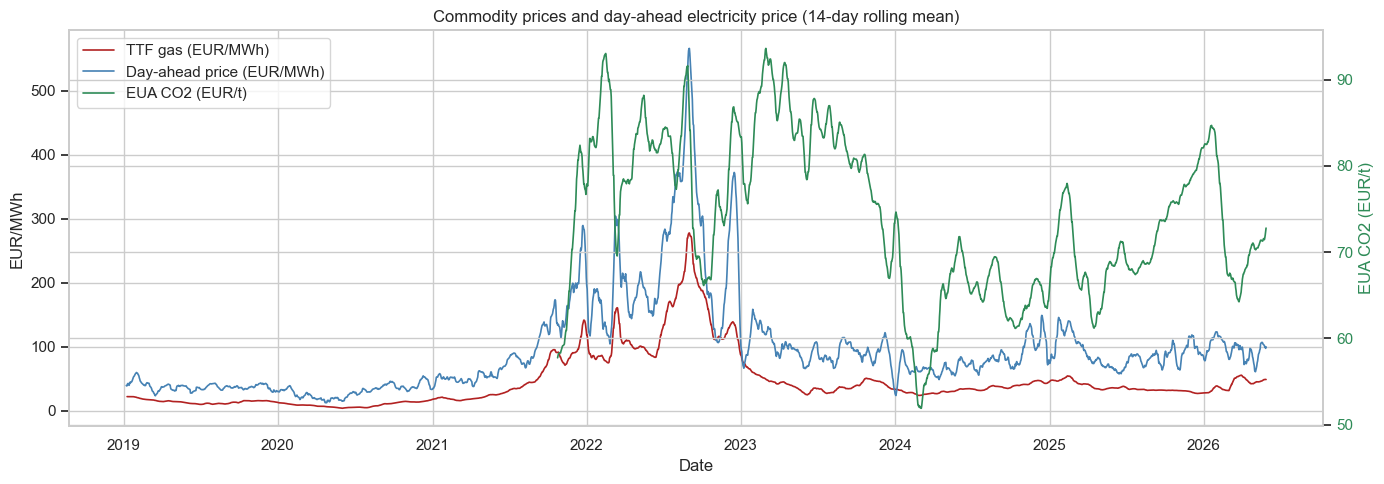

In [21]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ttf_daily = df["ttf_gas_eur_per_mwh"].resample("D").last().rolling(14, min_periods=7).mean()
eua_daily = df["eua_co2_eur_per_t"].resample("D").last().rolling(14, min_periods=7).mean()
price_daily = df["day_ahead_price"].resample("D").mean().rolling(14, min_periods=7).mean()

(l1,) = ax1.plot(ttf_daily.index, ttf_daily.values, color="firebrick", lw=1.2, label="TTF gas (EUR/MWh)")
(l2,) = ax1.plot(price_daily.index, price_daily.values, color="steelblue", lw=1.2, label="Day-ahead price (EUR/MWh)")
(l3,) = ax2.plot(eua_daily.index, eua_daily.values, color="seagreen", lw=1.2, label="EUA CO2 (EUR/t)")

ax1.set_ylabel("EUR/MWh")
ax2.set_ylabel("EUA CO2 (EUR/t)", color="seagreen")
ax1.set_xlabel("Date")
ax1.set_title("Commodity prices and day-ahead electricity price (14-day rolling mean)")

ax2.tick_params(axis="y", labelcolor="seagreen")

ax1.legend(handles=[l1, l2, l3], loc="upper left")
plt.tight_layout()
plt.show()

TTF gas prices spike dramatically in 2022, reaching ~300 EUR/MWh, before partially mean-reverting — but notably settling at a post-crisis level clearly above the pre-2021 baseline, suggesting a structural shift in the European gas market. EUA CO2 prices show a steadier upward trend from ~25 EUR/t in 2019 to ~60–70 EUR/t by 2023. The gap in the CO2 line before late 2021 reflects missing data, as the EUA ticker only became reliably available from that point onward.

The day-ahead electricity price tracks TTF gas very closely throughout — the co-movement is visually much stronger for gas than for CO2, consistent with gas-fired generation setting the marginal price for a large share of hours. The CO2 price contributes to the electricity price level but does not appear to drive its short-term dynamics as strongly (to be quantified in section 5.5c).

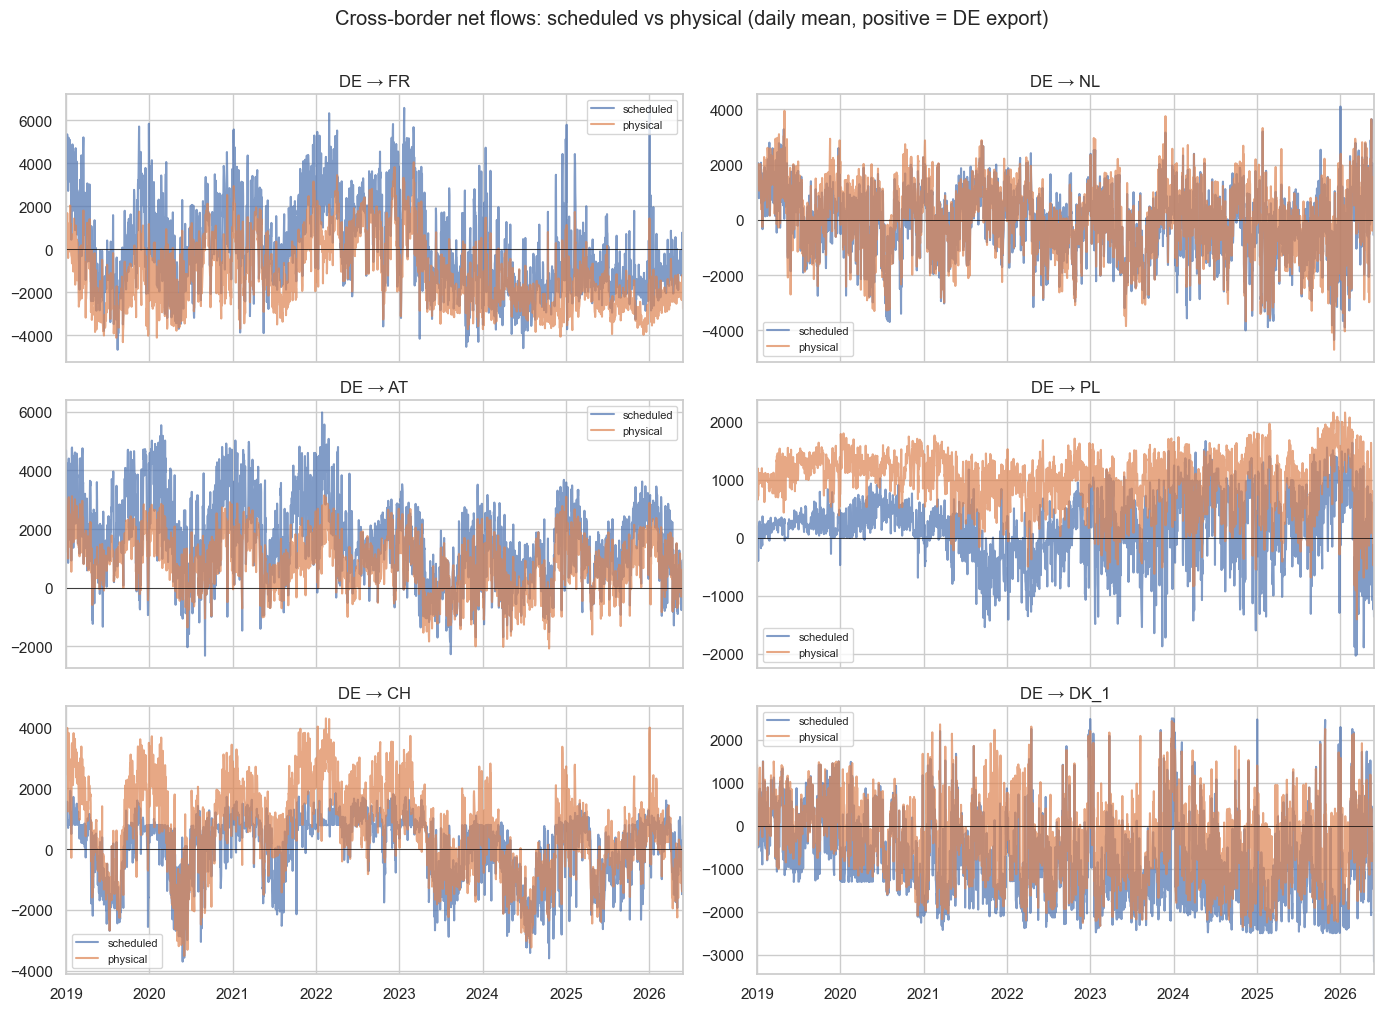

In [22]:
from typing import Sequence


def plot_border_flows_grid(frame: pd.DataFrame, neighbors: Sequence[str]) -> None:
    """Plot scheduled vs physical net flows for all neighbors as subplot grid."""
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    daily = frame.resample("D").mean()
    for ax, nb in zip(axes.flat, neighbors):
        sched_col = f"scheduled_net_de_to_{nb}"
        phys_col = f"physical_net_de_to_{nb}"
        if sched_col in daily.columns:
            daily[sched_col].plot(ax=ax, label="scheduled", alpha=0.7)
        if phys_col in daily.columns:
            daily[phys_col].plot(ax=ax, label="physical", alpha=0.7)
        ax.axhline(0, color="black", lw=0.5)
        ax.set_title(f"DE \u2192 {nb.upper()}")
        ax.legend(fontsize=8)
    plt.suptitle("Cross-border net flows: scheduled vs physical (daily mean, positive = DE export)", y=1.01)
    plt.tight_layout()
    plt.show()


NEIGHBORS = ["fr", "nl", "at", "pl", "ch", "dk_1"]
plot_border_flows_grid(df, NEIGHBORS)

Scheduled and physical flows track each other closely for most neighbors, validating the ENTSO-E data consistency. France and the Netherlands are the largest flow corridors; Austria and Switzerland show smaller but consistently directional flows. The 2022 energy crisis is visible as a shift in flow directions for some corridors, reflecting the reconfiguration of European energy trade routes.

### 2.2 Missingness Analysis

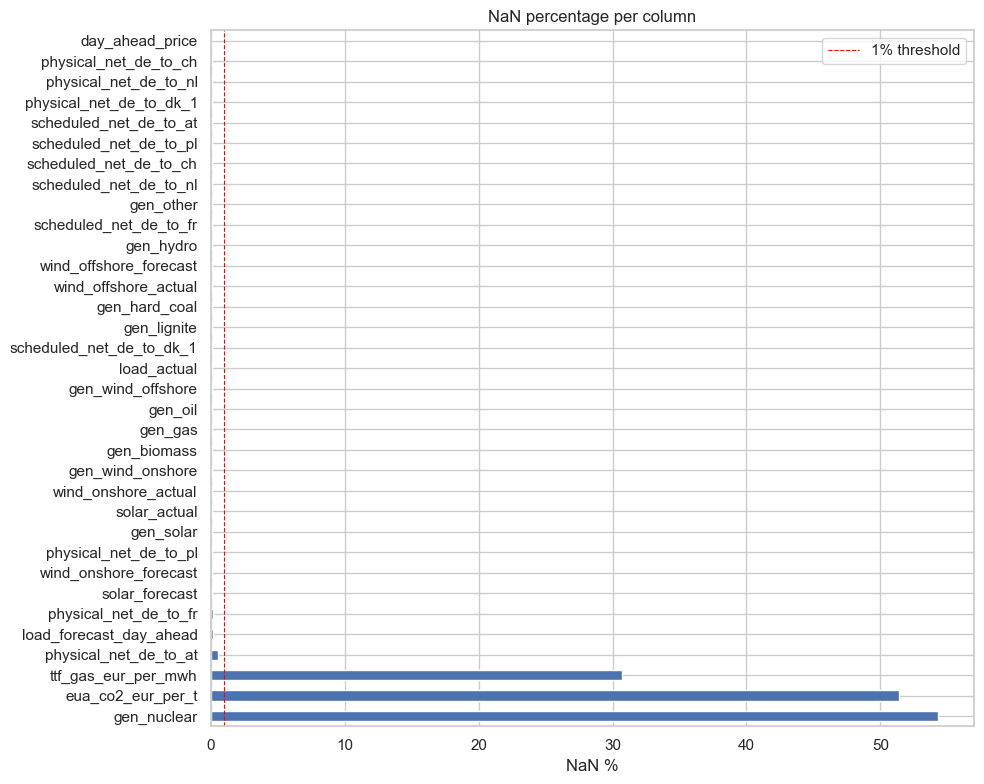

In [23]:
nan_pct = df.isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 8))
nan_pct.plot.barh(ax=ax)
ax.set_title("NaN percentage per column")
ax.set_xlabel("NaN %")
ax.axvline(1, color="red", lw=0.8, linestyle="--", label="1% threshold")
ax.legend()
plt.tight_layout()
plt.show()

Three columns stand out: `eua_co2_eur_per_t` (~38%), `gen_nuclear`, and `ttf_gas_eur_per_mwh`. All other columns are below 1%. The three outliers warrant a closer look at their missingness pattern over time.

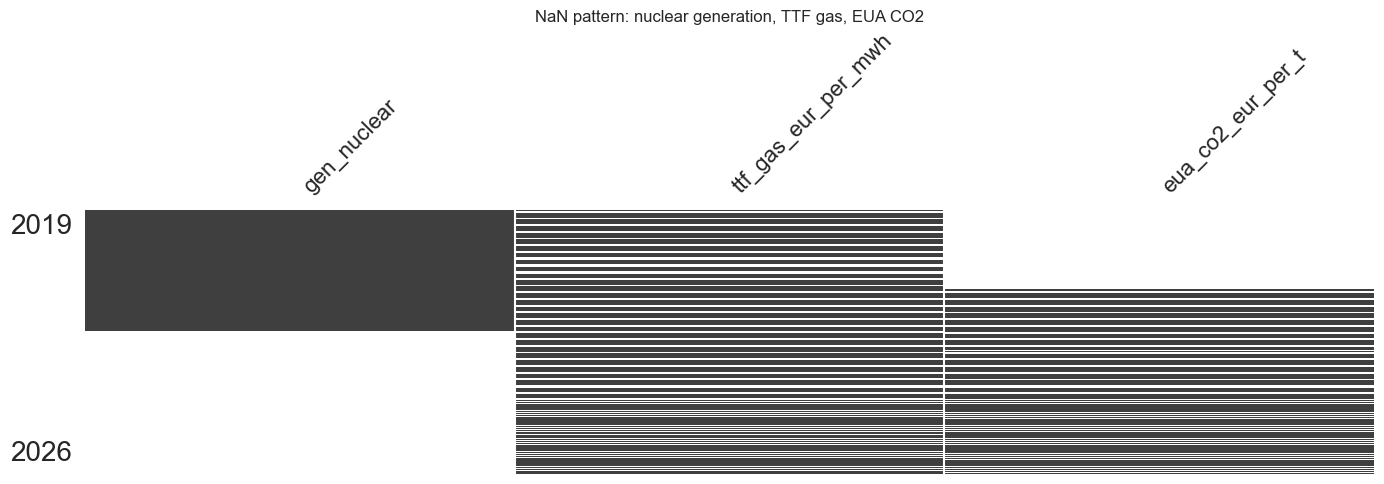

In [24]:
focus_cols = [c for c in ["gen_nuclear", "ttf_gas_eur_per_mwh", "eua_co2_eur_per_t"] if c in df.columns]
df_plot = df[focus_cols].copy()
df_plot.index = df_plot.index.tz_convert(None)

fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(df_plot, freq="ME", ax=ax, sparkline=False)

# Nur Anfangs- und Endpunkt auf der Zeitachse
years = sorted(df_plot.index.year.unique())
tick_positions, tick_labels = [], []
for y in [years[0], years[-1]]:
    rows = np.where(df_plot.index.year == y)[0]
    if len(rows):
        tick_positions.append(int(rows[len(rows) // 2]))
        tick_labels.append(str(y))
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

ax.set_title("NaN pattern: nuclear generation, TTF gas, EUA CO2")
plt.tight_layout()
plt.show()

The three patterns are structurally different and all expected:

**Nuclear (`gen_nuclear`):** Data is present from 2019 through early 2023, then drops to zero permanently from April 2023 onward — consistent with Germany's final nuclear shutdown. These are not missing values; the generation truly went to zero.

**EUA CO2 (`eua_co2_eur_per_t`):** Entirely absent before October 2021. The `CO2.L` ticker (ICE EUA Futures via Yahoo Finance) was not reliably available before that date. This is a structural data gap that cannot be recovered. After that gap Data ist still missing, seemingly at random. These gaps are likely caused by Yahoo Finance data quality issues: futures tickers are prone to gaps during contract rollovers, and Yahoo Finance does not provide a professionally maintained feed for commodity futures. A production system would source TTF and EUA data from EEX or ICE directly. For EDA purposes, the gaps are noted and left as NaN.

**TTF gas (`ttf_gas_eur_per_mwh`):** Present throughout, but with intermittent gaps beyond what weekends and holidays alone would explain. The loader forward-fills both commodity columns with a 4-day limit, which covers normal weekend and holiday gaps. Longer gaps are likely caused by Yahoo Finance data quality issues: futures tickers are prone to gaps during contract rollovers, and Yahoo Finance does not provide a professionally maintained feed for commodity futures. A production system would source TTF and EUA data from EEX or ICE directly. For EDA purposes, the gaps are noted and left as NaN.

 **Time resolution change:** There is a change in the structure of the data visible. From 2025-09-30 22:15 UTC onward, ENTSO-E publishes data at 15-minute resolution instead of hourly. The current DataFrame contains a mix of 59,166 hourly and 22,824 quarter-hourly rows. As missingno is not built for a time-index, this becomes visible and must be minded when further using the data.

### 2.3 Plausibility Checks

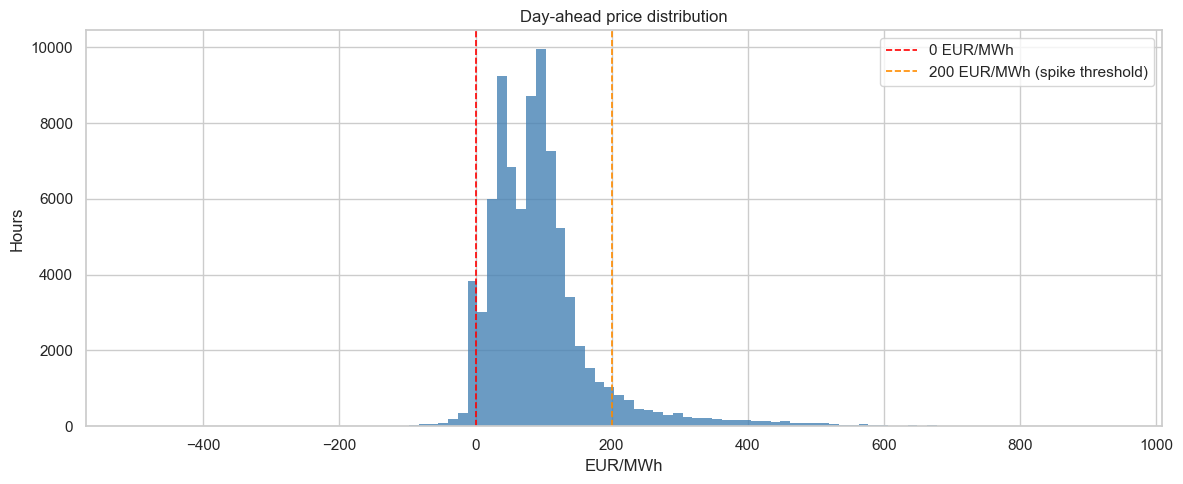

Negative price hours:            3,133 (3.82% of total)
Spike hours (>200 EUR/MWh):    6,299 (7.67% of total)
Extreme spike hours (>500 EUR/MWh):    531 (0.65% of total)


In [25]:
SPIKE_THRESHOLD_EUR = 200
EXTREME_SPIKE_THRESHOLD_EUR = 500
NEG_PRICE_THRESHOLD = 0

price = df["day_ahead_price"].dropna()
total = len(price)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(price, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(NEG_PRICE_THRESHOLD, color="red", lw=1.2, linestyle="--", label="0 EUR/MWh")
ax.axvline(
    SPIKE_THRESHOLD_EUR, color="darkorange", lw=1.2, linestyle="--",
    label=f"{SPIKE_THRESHOLD_EUR} EUR/MWh (spike threshold)",
)
ax.set_title("Day-ahead price distribution")
ax.set_xlabel("EUR/MWh")
ax.set_ylabel("Hours")
ax.legend()
plt.tight_layout()
plt.show()

neg = (price < NEG_PRICE_THRESHOLD).sum()
spikes = (price > SPIKE_THRESHOLD_EUR).sum()
extreme = (price > EXTREME_SPIKE_THRESHOLD_EUR).sum()
print(f"Negative price hours:           {neg:>6,} ({neg / total:.2%} of total)")
print(f"Spike hours (>{SPIKE_THRESHOLD_EUR} EUR/MWh):   {spikes:>6,} ({spikes / total:.2%} of total)")
print(f"Extreme spike hours (>{EXTREME_SPIKE_THRESHOLD_EUR} EUR/MWh): {extreme:>6,} ({extreme / total:.2%} of total)")

The price distribution is strongly right-skewed with the bulk of hours concentrated between 0 and 100 EUR/MWh; a long right tail reflects the 2022 crisis period. Negative prices occur in a small but non-negligible share of hours, driven by renewable surplus (typically weekend middays with high solar and low demand). Extreme spikes above 500 EUR/MWh are very rare and concentrated in 2022.

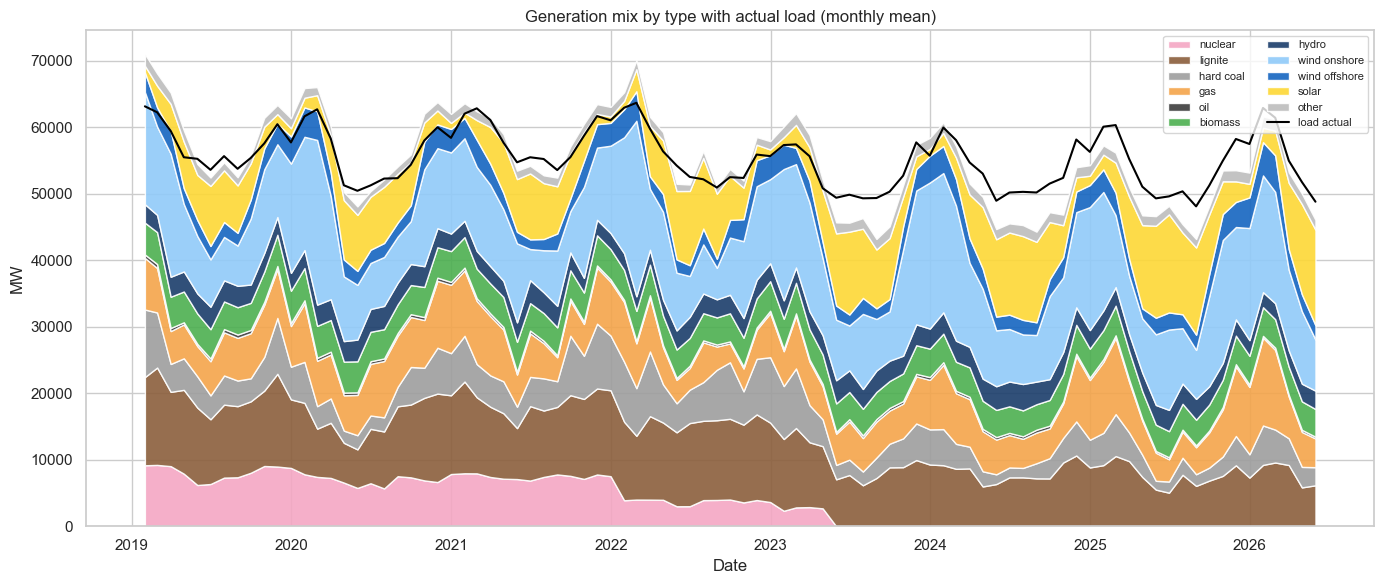

In [26]:
gen_order = [
    "gen_nuclear", "gen_lignite", "gen_hard_coal", "gen_gas", "gen_oil",
    "gen_biomass", "gen_hydro", "gen_wind_onshore", "gen_wind_offshore",
    "gen_solar", "gen_other",
]
_GEN_COLORS = {
    "gen_nuclear":       "#f4a7c3",  # rosa
    "gen_lignite":       "#8b5e3c",  # braun
    "gen_hard_coal":     "#9e9e9e",  # grau
    "gen_gas":           "#f4a44a",  # orange
    "gen_oil":           "#3d3d3d",  # dunkelgrau
    "gen_biomass":       "#4caf50",  # grün
    "gen_hydro":         "#1a3d6b",  # dunkelblau
    "gen_wind_onshore":  "#90caf9",  # hellblau
    "gen_wind_offshore": "#1565c0",  # blau
    "gen_solar":         "#fdd835",  # gelb
    "gen_other":         "#bdbdbd",  # hellgrau
}
available_gen = [c for c in gen_order if c in df.columns]
# fillna(0): after the nuclear shutdown ENTSO-E stops reporting the column entirely,
# producing NaN in the concatenated DataFrame — stackplot aborts at the first NaN.
monthly_gen = df[available_gen].resample("ME").mean().fillna(0)
monthly_load = df["load_actual"].resample("ME").mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    monthly_gen.index,
    [monthly_gen[c] for c in available_gen],
    labels=[c.replace("gen_", "").replace("_", " ") for c in available_gen],
    colors=[_GEN_COLORS[c] for c in available_gen],
    alpha=0.9,
)
ax.plot(monthly_load.index, monthly_load.values, color="black", lw=1.5, label="load actual", zorder=5)
ax.set_title("Generation mix by type with actual load (monthly mean)")
ax.set_ylabel("MW")
ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=8, ncols=2)
plt.tight_layout()
plt.show()

The chart shows several expected structural patterns that validate the data quality.

**Seasonal stack height:** Total generation is consistently higher in winter months than in summer, which is plausible — higher electricity demand for heating, lighting, and industrial activity during the cold season drives more capacity into dispatch. This seasonality is visible as a regular annual rhythm in the overall stack height throughout the full 2019–2026 range.

**Solar (yellow):** Peaks sharply each summer and nearly vanishes in winter. This is the physically expected behaviour: longer days and higher solar angles in June–August maximise photovoltaic yield, while winter months with short, low-angle days contribute very little. The summer peaks grow noticeably from 2019 to 2026, consistent with continued capacity additions.

**Wind onshore (light blue) and offshore (blue):** Both sources peak in winter and trough in summer — the seasonal complement to solar. Northern European wind patterns are stronger and more frequent in autumn and winter, making wind the dominant renewable in the darker half of the year. Together, wind and solar provide a natural seasonal hedge against each other.

**Nuclear (pink):** Visible as a steady base-load layer through 2022 and into early 2023, then disappears entirely after Germany's final three-plant shutdown in April 2023. The column becomes NaN in the ENTSO-E data post-shutdown (the source stops reporting it); the `fillna(0)` applied before plotting reflects the true physical state: zero generation.

**Lignite (brown) and hard coal (grey):** Remain substantial base-load contributors throughout, though with some visible reduction from 2023 onward as renewables displace them at the margin. The two coal types together represent the largest single share of the stack in the pre-crisis period.

**Gas (orange):** Shows more variability, often filling residual demand left by weather-driven swings in wind and solar. Its contribution spikes in some winter months and recedes when renewables are strong.

**Actual load (black line):** The load line runs until the crisis below the total generation stack. This is expected: Germany was structurally a net exporter of electricity, and the gap between domestic generation and domestic consumption represents net cross-border exports. The gap narrows during the 2022 energy crisis — consistent with Germany reducing exports and importing more during periods of extreme gas scarcity — and widens again afterward in the opposite direction underlining the change from an exporter toward an importer. The load line mirrors the seasonal rhythm of the stack, confirming that generation broadly follows demand across the year.

In [27]:
df.describe()

,day_ahead_price,load_actual,load_forecast_day_ahead,wind_onshore_forecast,wind_offshore_forecast,solar_forecast,wind_onshore_actual,wind_offshore_actual,solar_actual,gen_nuclear,gen_lignite,gen_hard_coal,gen_gas,gen_oil,gen_biomass,gen_wind_onshore,gen_wind_offshore,gen_solar,gen_hydro,gen_other,scheduled_net_de_to_fr,scheduled_net_de_to_nl,scheduled_net_de_to_at,scheduled_net_de_to_pl,scheduled_net_de_to_ch,scheduled_net_de_to_dk_1,physical_net_de_to_fr,physical_net_de_to_nl,physical_net_de_to_at,physical_net_de_to_pl,physical_net_de_to_ch,physical_net_de_to_dk_1,ttf_gas_eur_per_mwh,eua_co2_eur_per_t
count,82087.000000,81999.000000,81949.000000,81993.000000,81999.000000,81993.000000,81998.000000,81999.000000,81998.000000,37531.000000,81999.000000,81999.000000,81998.000000,81998.000000,81998.000000,81998.000000,81999.000000,81998.000000,81999.000000,81999.000000,81999.000000,81999.000000,81999.000000,81999.000000,81999.000000,81999.000000,81991.000000,81999.000000,81681.000000,81997.000000,81999.000000,81999.000000,56893.000000,39917.000000
mean,94.912717,55596.645345,55148.047877,12480.815596,3044.873897,6476.628655,12510.228046,3097.355069,6440.544708,6304.134968,9380.292530,4569.958142,7006.326873,356.211488,4315.583718,12510.228046,3097.355069,6440.544708,2814.217707,1458.647829,-200.330329,-144.101812,1637.693238,232.907566,113.282974,-915.156953,-1491.094199,2.896848,902.969321,1057.084576,571.406672,-321.498868,43.590037,74.196744
std,85.491319,9727.908866,9188.692365,9621.928084,1966.815387,10389.831151,9656.158635,2090.795913,10414.757790,2082.782945,3599.675083,3085.891126,3749.610521,113.327818,330.646666,9656.158635,2090.795913,10414.757790,1589.276745,256.176180,2358.397577,1651.809474,1671.092215,810.538841,1409.347300,1431.451165,1734.044575,1751.276887,1164.701708,695.412661,1644.778914,1182.545729,39.351842,8.569981
min,-500.000000,28407.440000,30848.600000,151.000000,12.300000,0.000000,43.480000,0.000000,0.006000,572.910000,1337.332000,136.160000,1265.960000,36.980000,3084.200000,43.480000,0.000000,0.006000,877.860000,547.631000,-7335.200000,-6839.000000,-4434.200000,-3140.600000,-4065.000000,-3500.000000,-5223.070000,-6579.009990,-3184.508000,-2636.730000,-5245.720000,-2924.480000,3.510000,49.665001
25%,41.650000,47700.961325,47632.680000,4846.700000,1213.695000,0.000000,4807.447500,1190.885000,3.360000,4035.945000,6490.813695,2173.135000,4049.125000,290.670000,4076.245899,4807.447500,1190.885000,3.360000,1659.428225,1276.595000,-1896.550000,-1236.450000,448.150000,-126.250000,-446.723500,-2059.000000,-2857.741985,-1199.223750,88.910000,750.637000,-552.224000,-1212.905000,23.049999,67.635002
50%,84.600000,55478.180000,55087.100000,9826.315660,2936.060000,92.604180,9930.678026,2912.070000,70.770000,6673.600000,9760.750000,3880.330670,6296.838350,368.360000,4322.051952,9930.678026,2912.070000,70.770000,2259.160000,1480.860000,-878.300000,3.000000,1682.800000,293.600000,799.300000,-1300.000000,-1939.833500,149.780000,1030.287170,1193.160000,671.811680,-286.400000,33.116001,74.389999
75%,117.880000,63085.045000,62711.960000,17779.590000,4797.810000,9823.690000,17915.786169,4844.935000,9678.816232,7895.135000,12109.015000,6157.426735,9195.182923,406.030000,4566.110000,17915.786169,4844.935000,9678.816232,3517.675000,1663.225939,1449.600000,1009.900000,2805.300000,808.850000,800.185000,0.000000,-275.476750,1266.120000,1795.511800,1520.630000,1723.824000,388.160000,46.919998,80.754997
max,936.280000,81966.910000,78140.790000,46982.427710,7541.930000,57206.814350,48724.550000,8480.692000,54555.398000,9527.630000,17551.100000,16771.700000,20178.020000,1321.930000,5289.340000,48724.550000,8480.692000,54555.398000,10289.230000,2117.179910,9759.600000,8825.200000,7750.900000,5509.900000,2200.000000,3500.000000,4916.079000,6240.076650,4223.782000,2820.280000,5262.058593,2954.240000,339.196014,96.415001


The basic statistics show the expected range of values for the main columns. Negative values are only visible for the price and cross border flows. The max- and min-values, mean and quantiles are reasonable throughout.

### 2.4 DQ Findings

**Confirmed structural patterns (expected):**
- Load and generation seasonalities are clearly visible
- Strong structural break through the gas crisis
- Gas-Price seems to be one of the main price drivers
- Nuclear generation (gen_nuclear) tapers to zero by April 2023, reflecting Germany's final shutdown — this structural break affects the generation mix feature permanently.
- Renewable generation shows also strong seasonality (wind: winter peak, solar: summer peak) with a visible multi-year upward capacity trend.

**Data quality issues (need handling in feature engineering):**
- **Time resolution change:** From 2025-09-30 22:15 UTC onward, ENTSO-E publishes data at 15-minute resolution instead of hourly. The current DataFrame contains a mix of 59,166 hourly and 22,824 quarter-hourly rows. The loader does not normalise this — the mixed index will break any hourly feature pipeline. Sprint 2 must decide: resample 15-min data to hourly, or migrate the full pipeline to 15-min resolution.
- EUA CO2 data only available from October 2021 onward and missing for ~38% of the full time range (pre-Oct-2021); feature engineering must decide between truncating the training window or encoding missingness explicitly.
- Small NaN gaps (<1%) in several ENTSO-E columns (generation types, cross-border flows); forward-fill or linear interpolation over short gaps is likely appropriate in Sprint 2.
- Negative price hours exist and are legitimate market events (renewable surplus); any log-transformation of the target must account for these.
- Extreme price spikes (>500 EUR/MWh) are rare but real; outlier capping or robust loss functions should be considered for the model.

**Open questions (revisit later):**
- Are the simultaneous NaN bands across ENTSO-E columns due to API outages or genuine reporting gaps? Cross-check against ENTSO-E transparency platform directly.
- Is the change of the behaviour of load forecast error post crisis now permanent?
- Solar forecast overestimation at high output levels: is this a systematic ENTSO-E model bias or a data artefact? Relevant for how much weight to give the solar forecast as a feature.
- How stable is the scheduled-vs-physical flow relationship across the 2022 regime shift? Worth checking whether the divergence increases during the crisis period (5.5c).

## 3. Structural Insights

_To be filled in spec 5.5c: merit-order effect, seasonality patterns, regime shifts,
autocorrelation, cross-border price–flow relationship._

## 4. Findings and Next Steps

_To be filled in spec 5.5d: structured summary of insights and their implications
for feature engineering (Sprint 2)._